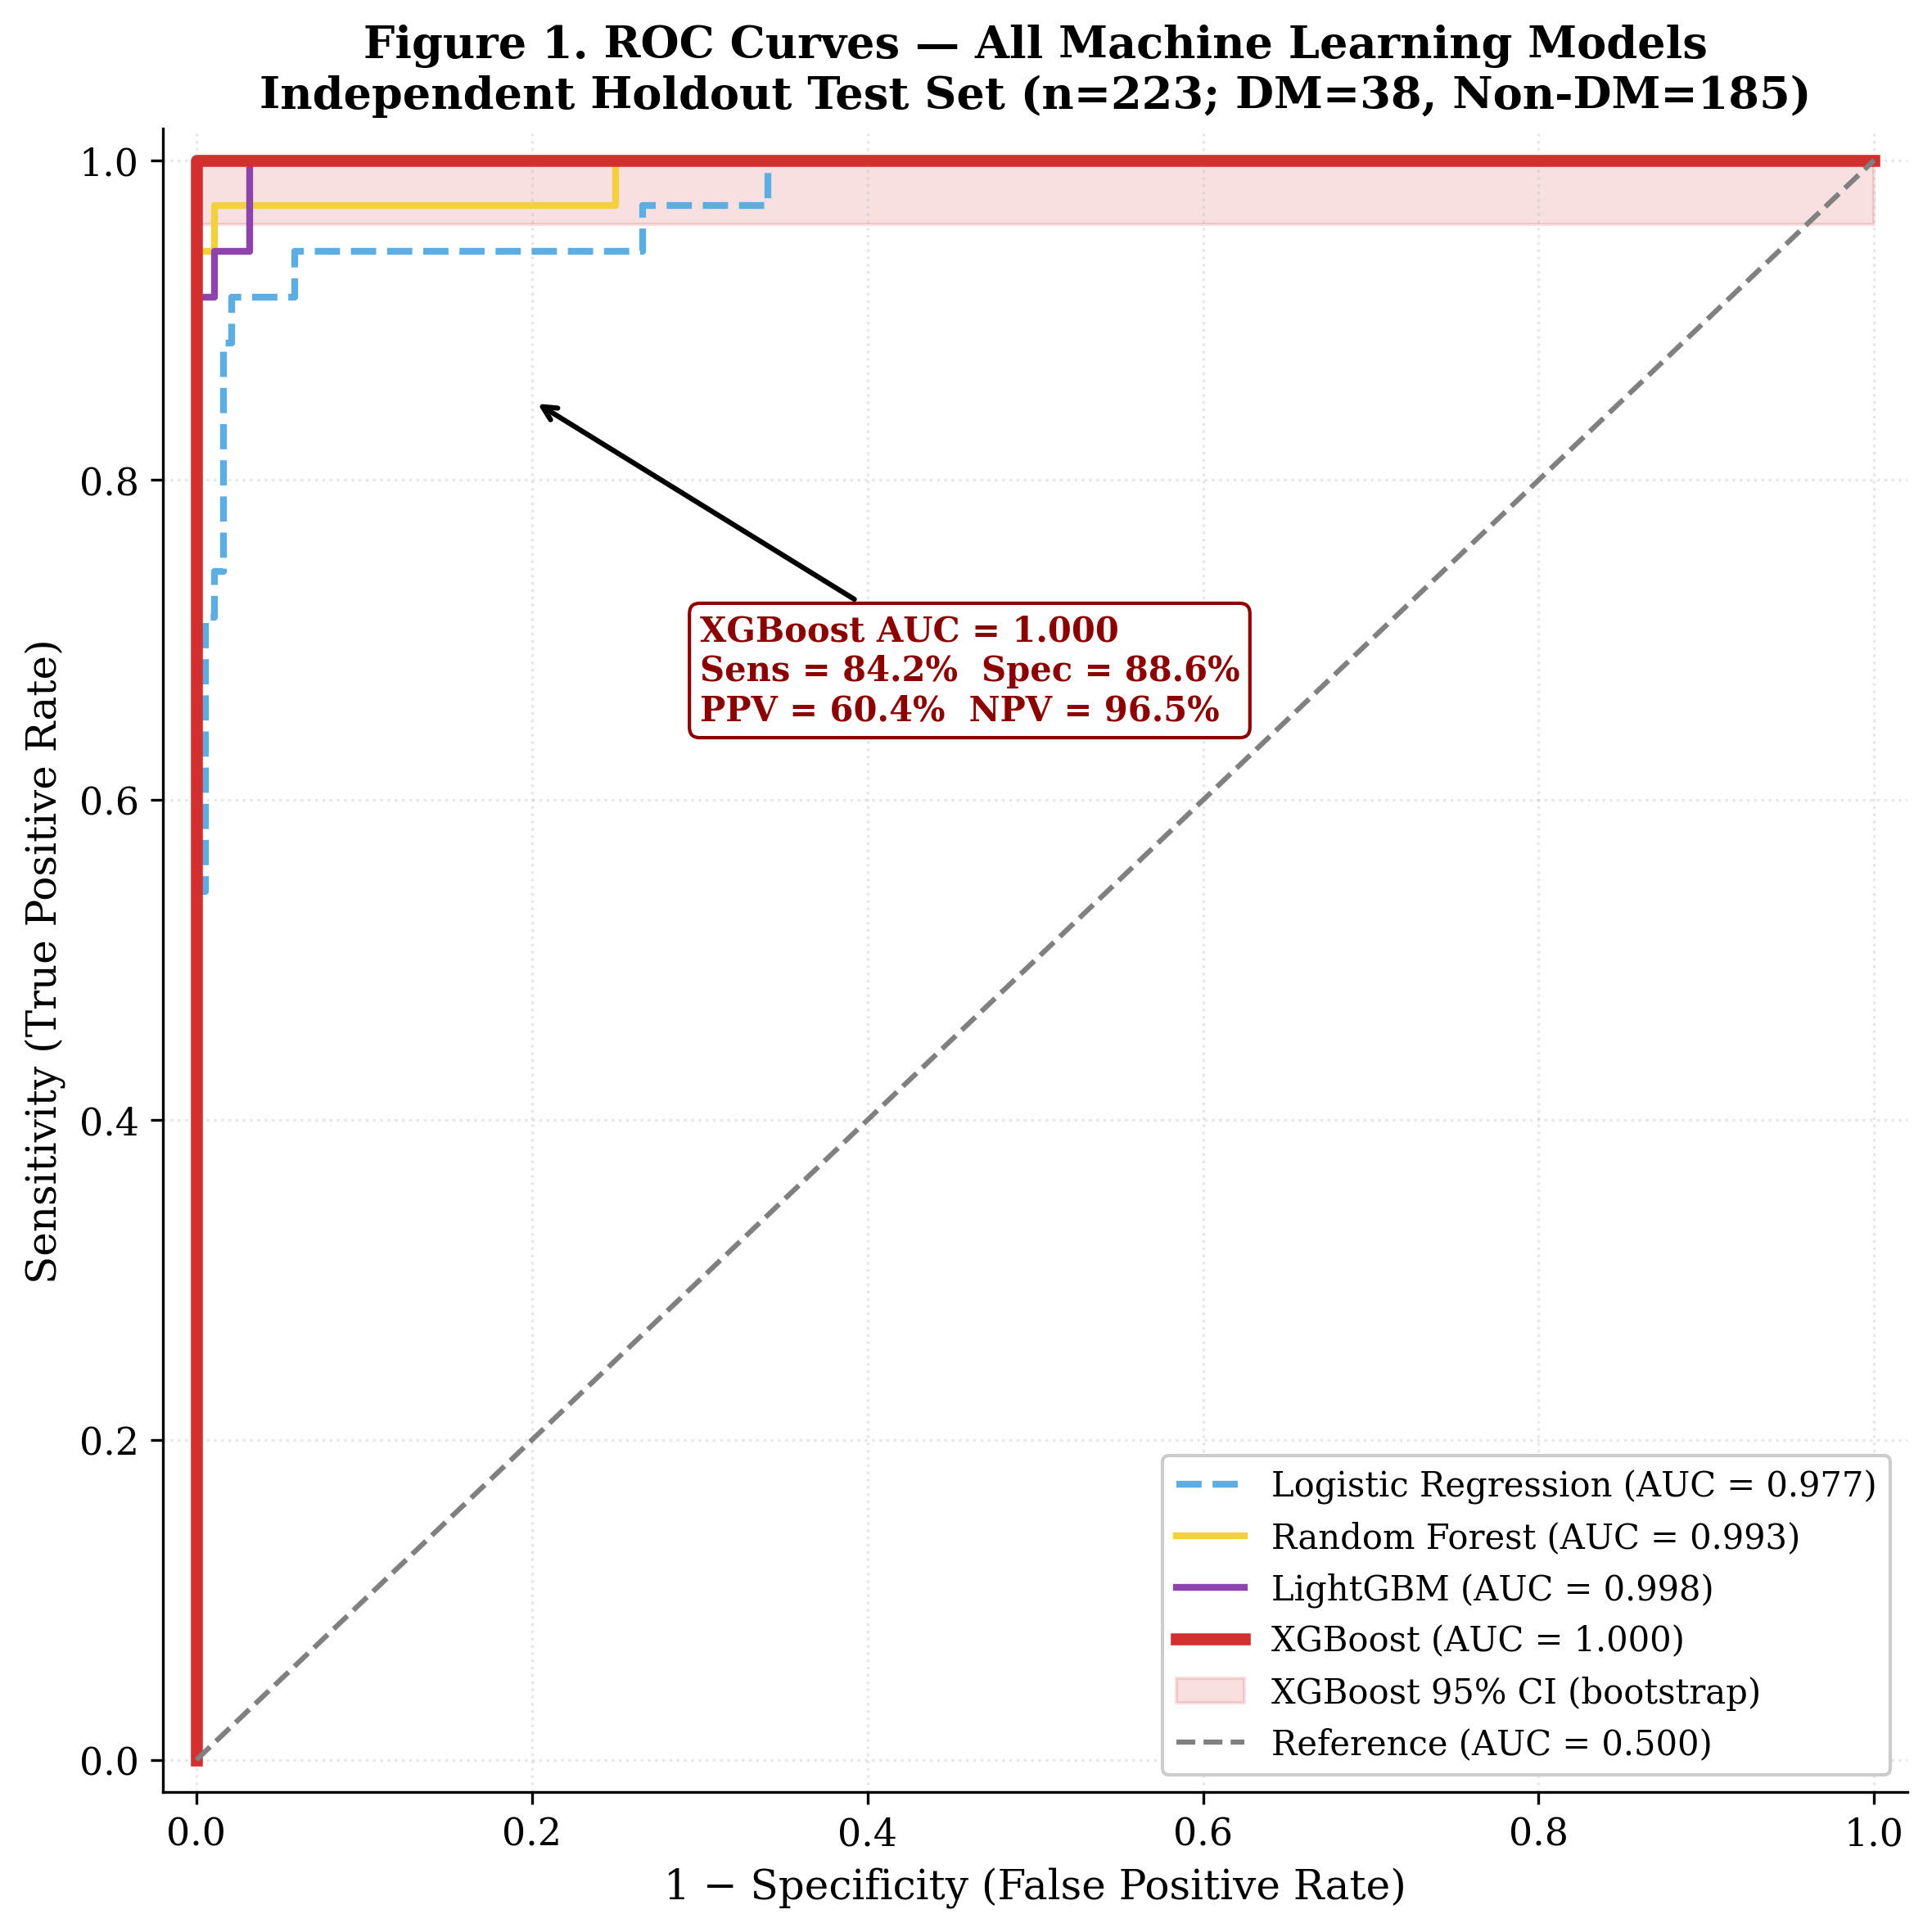

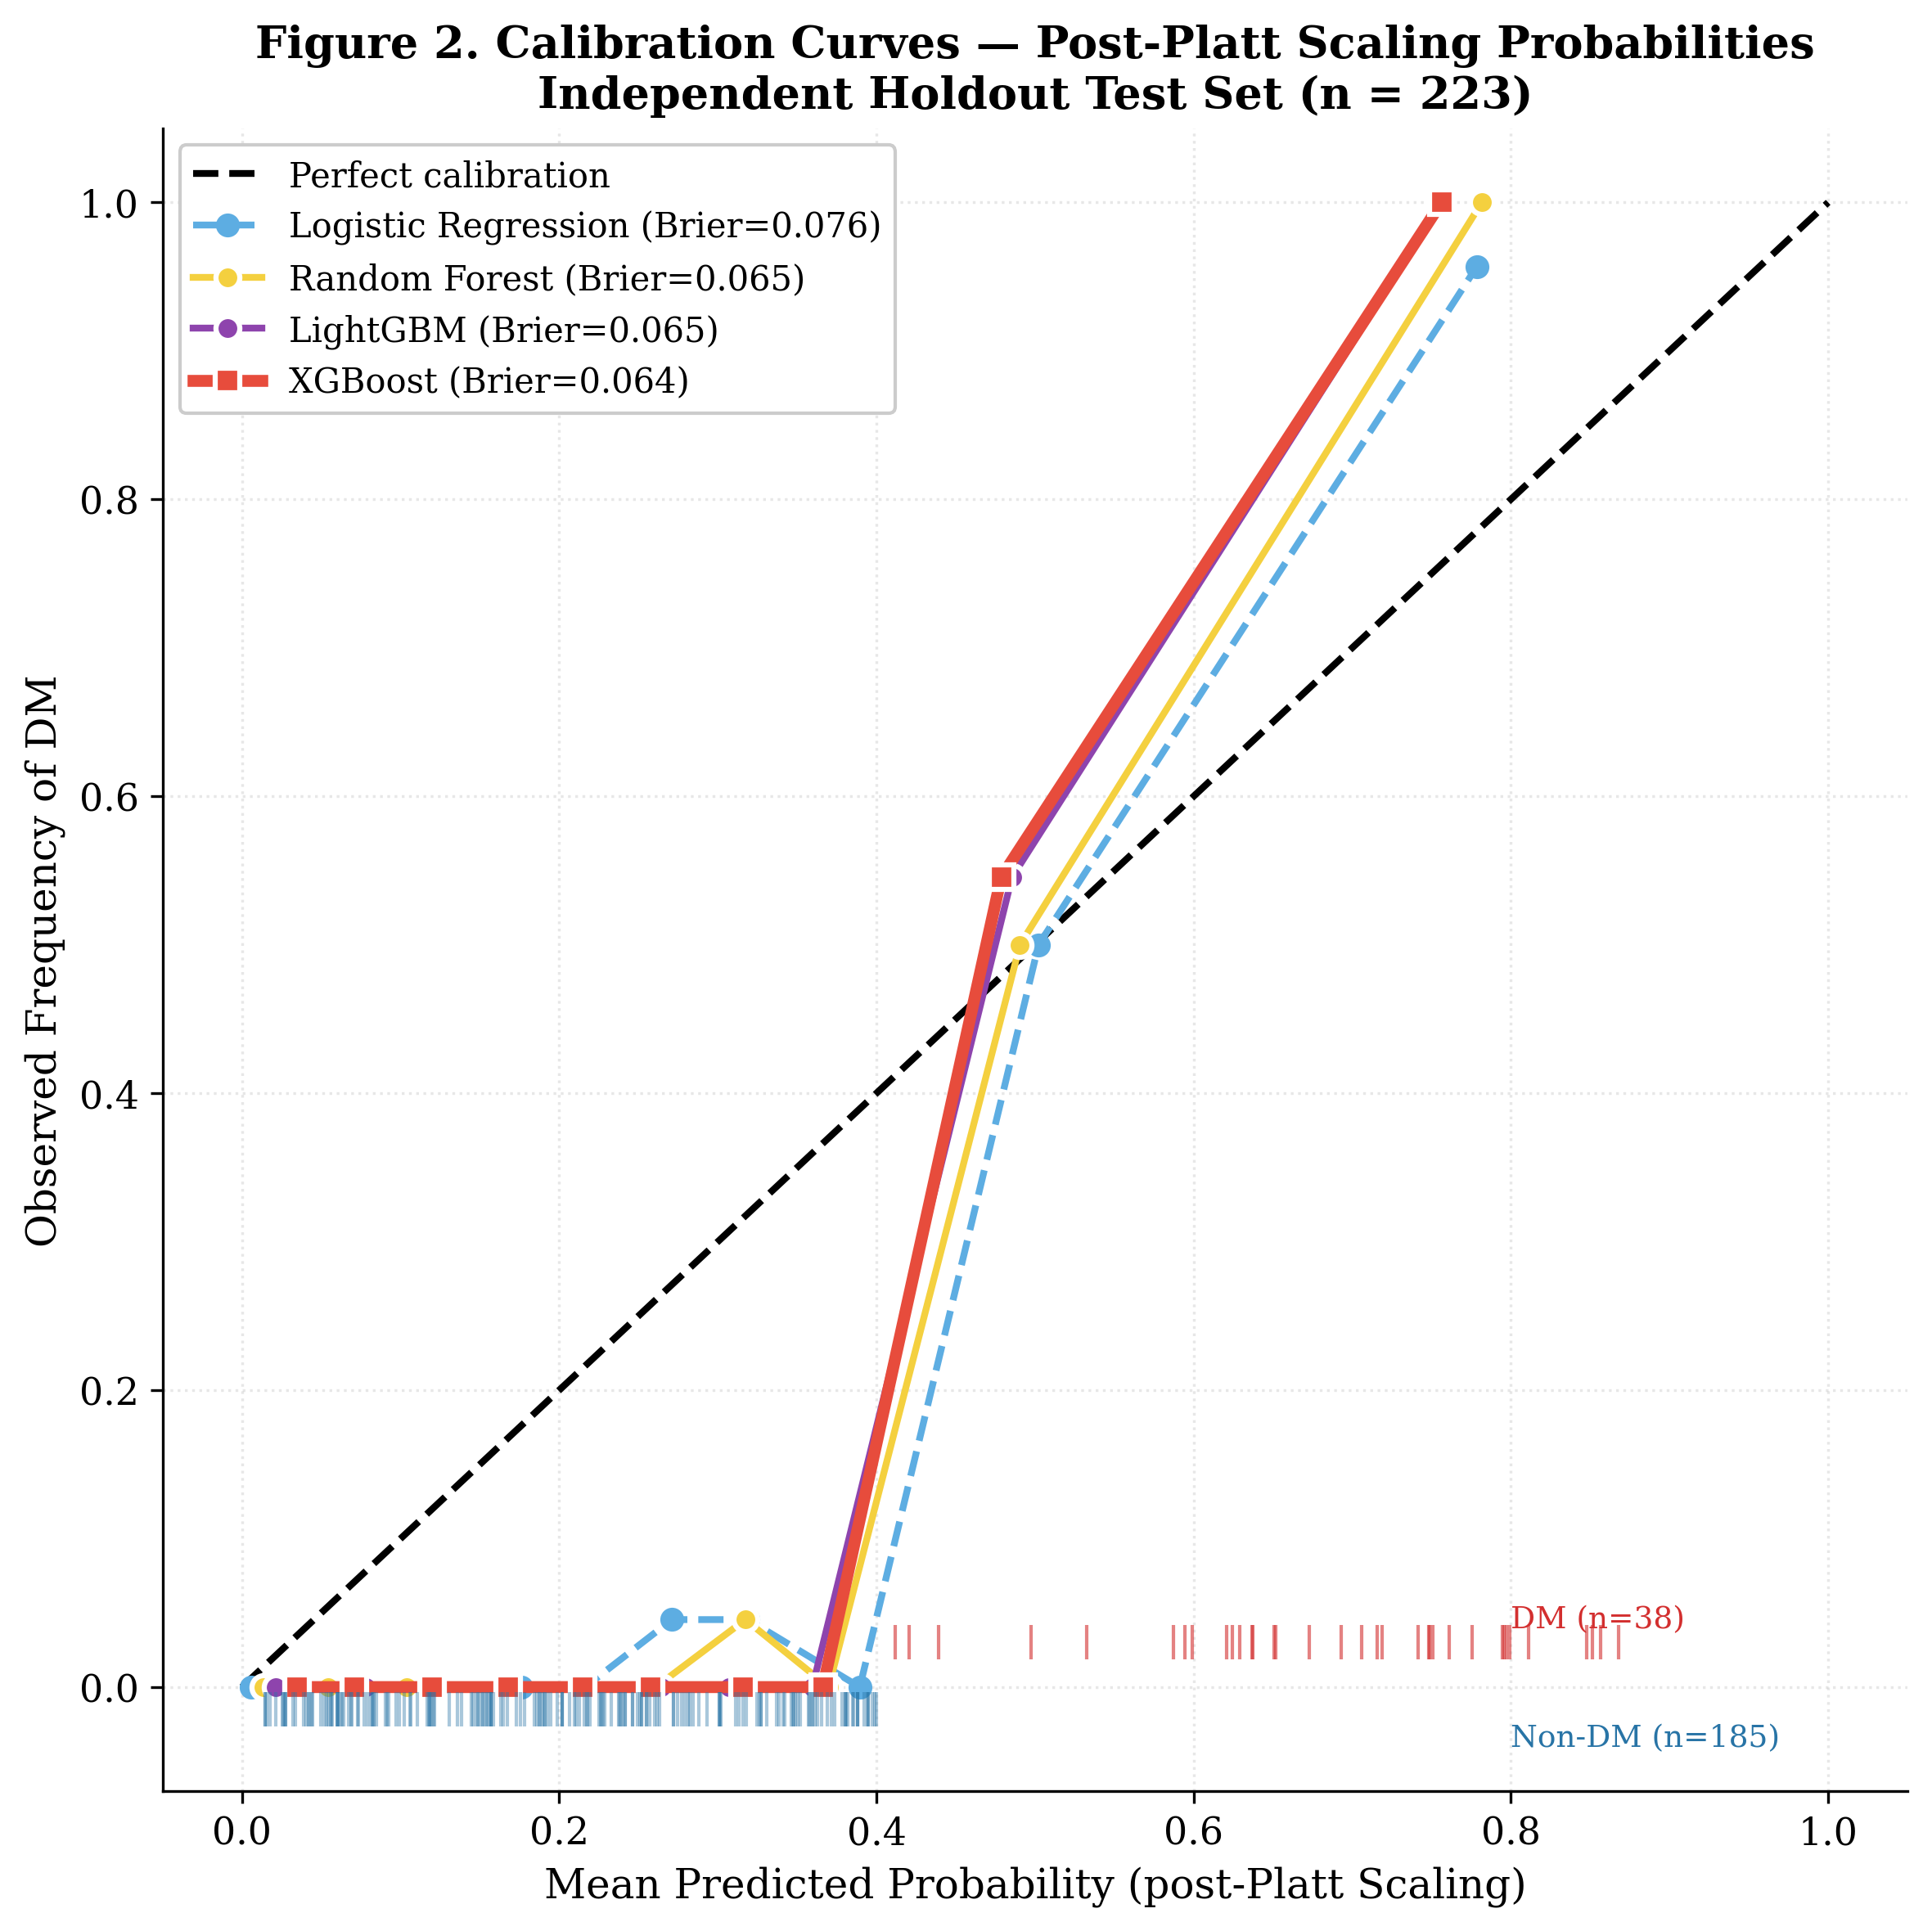

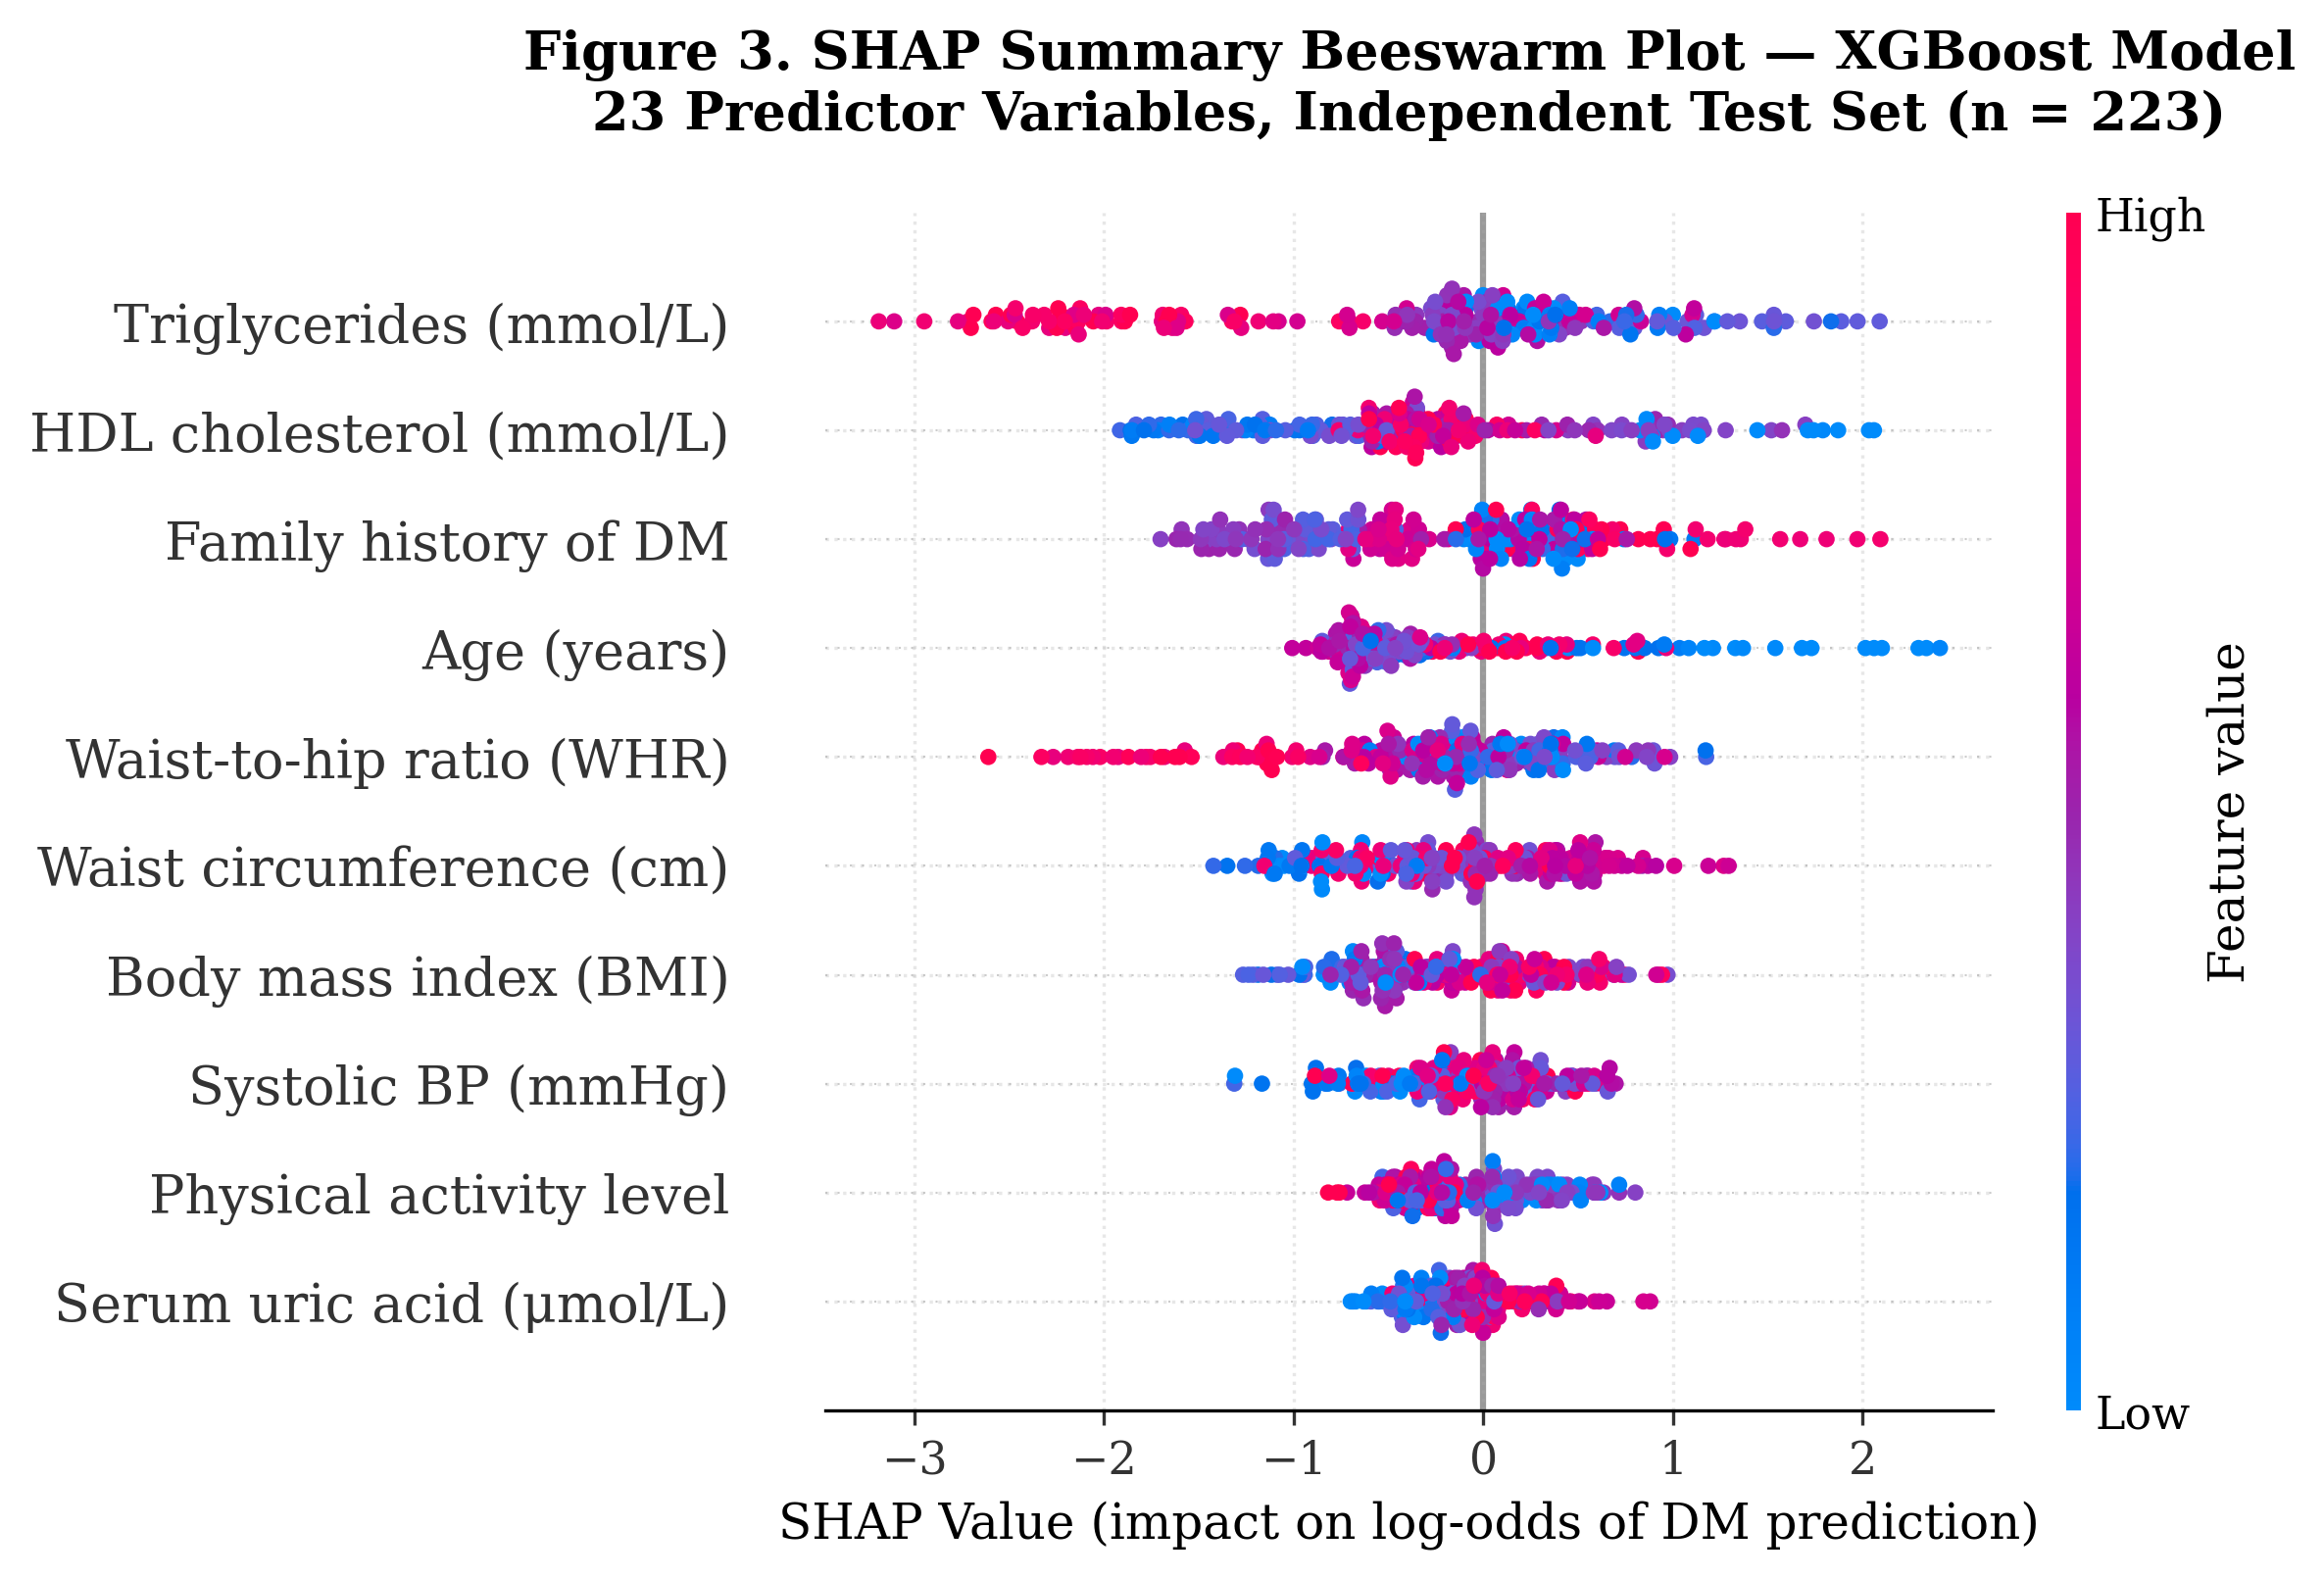

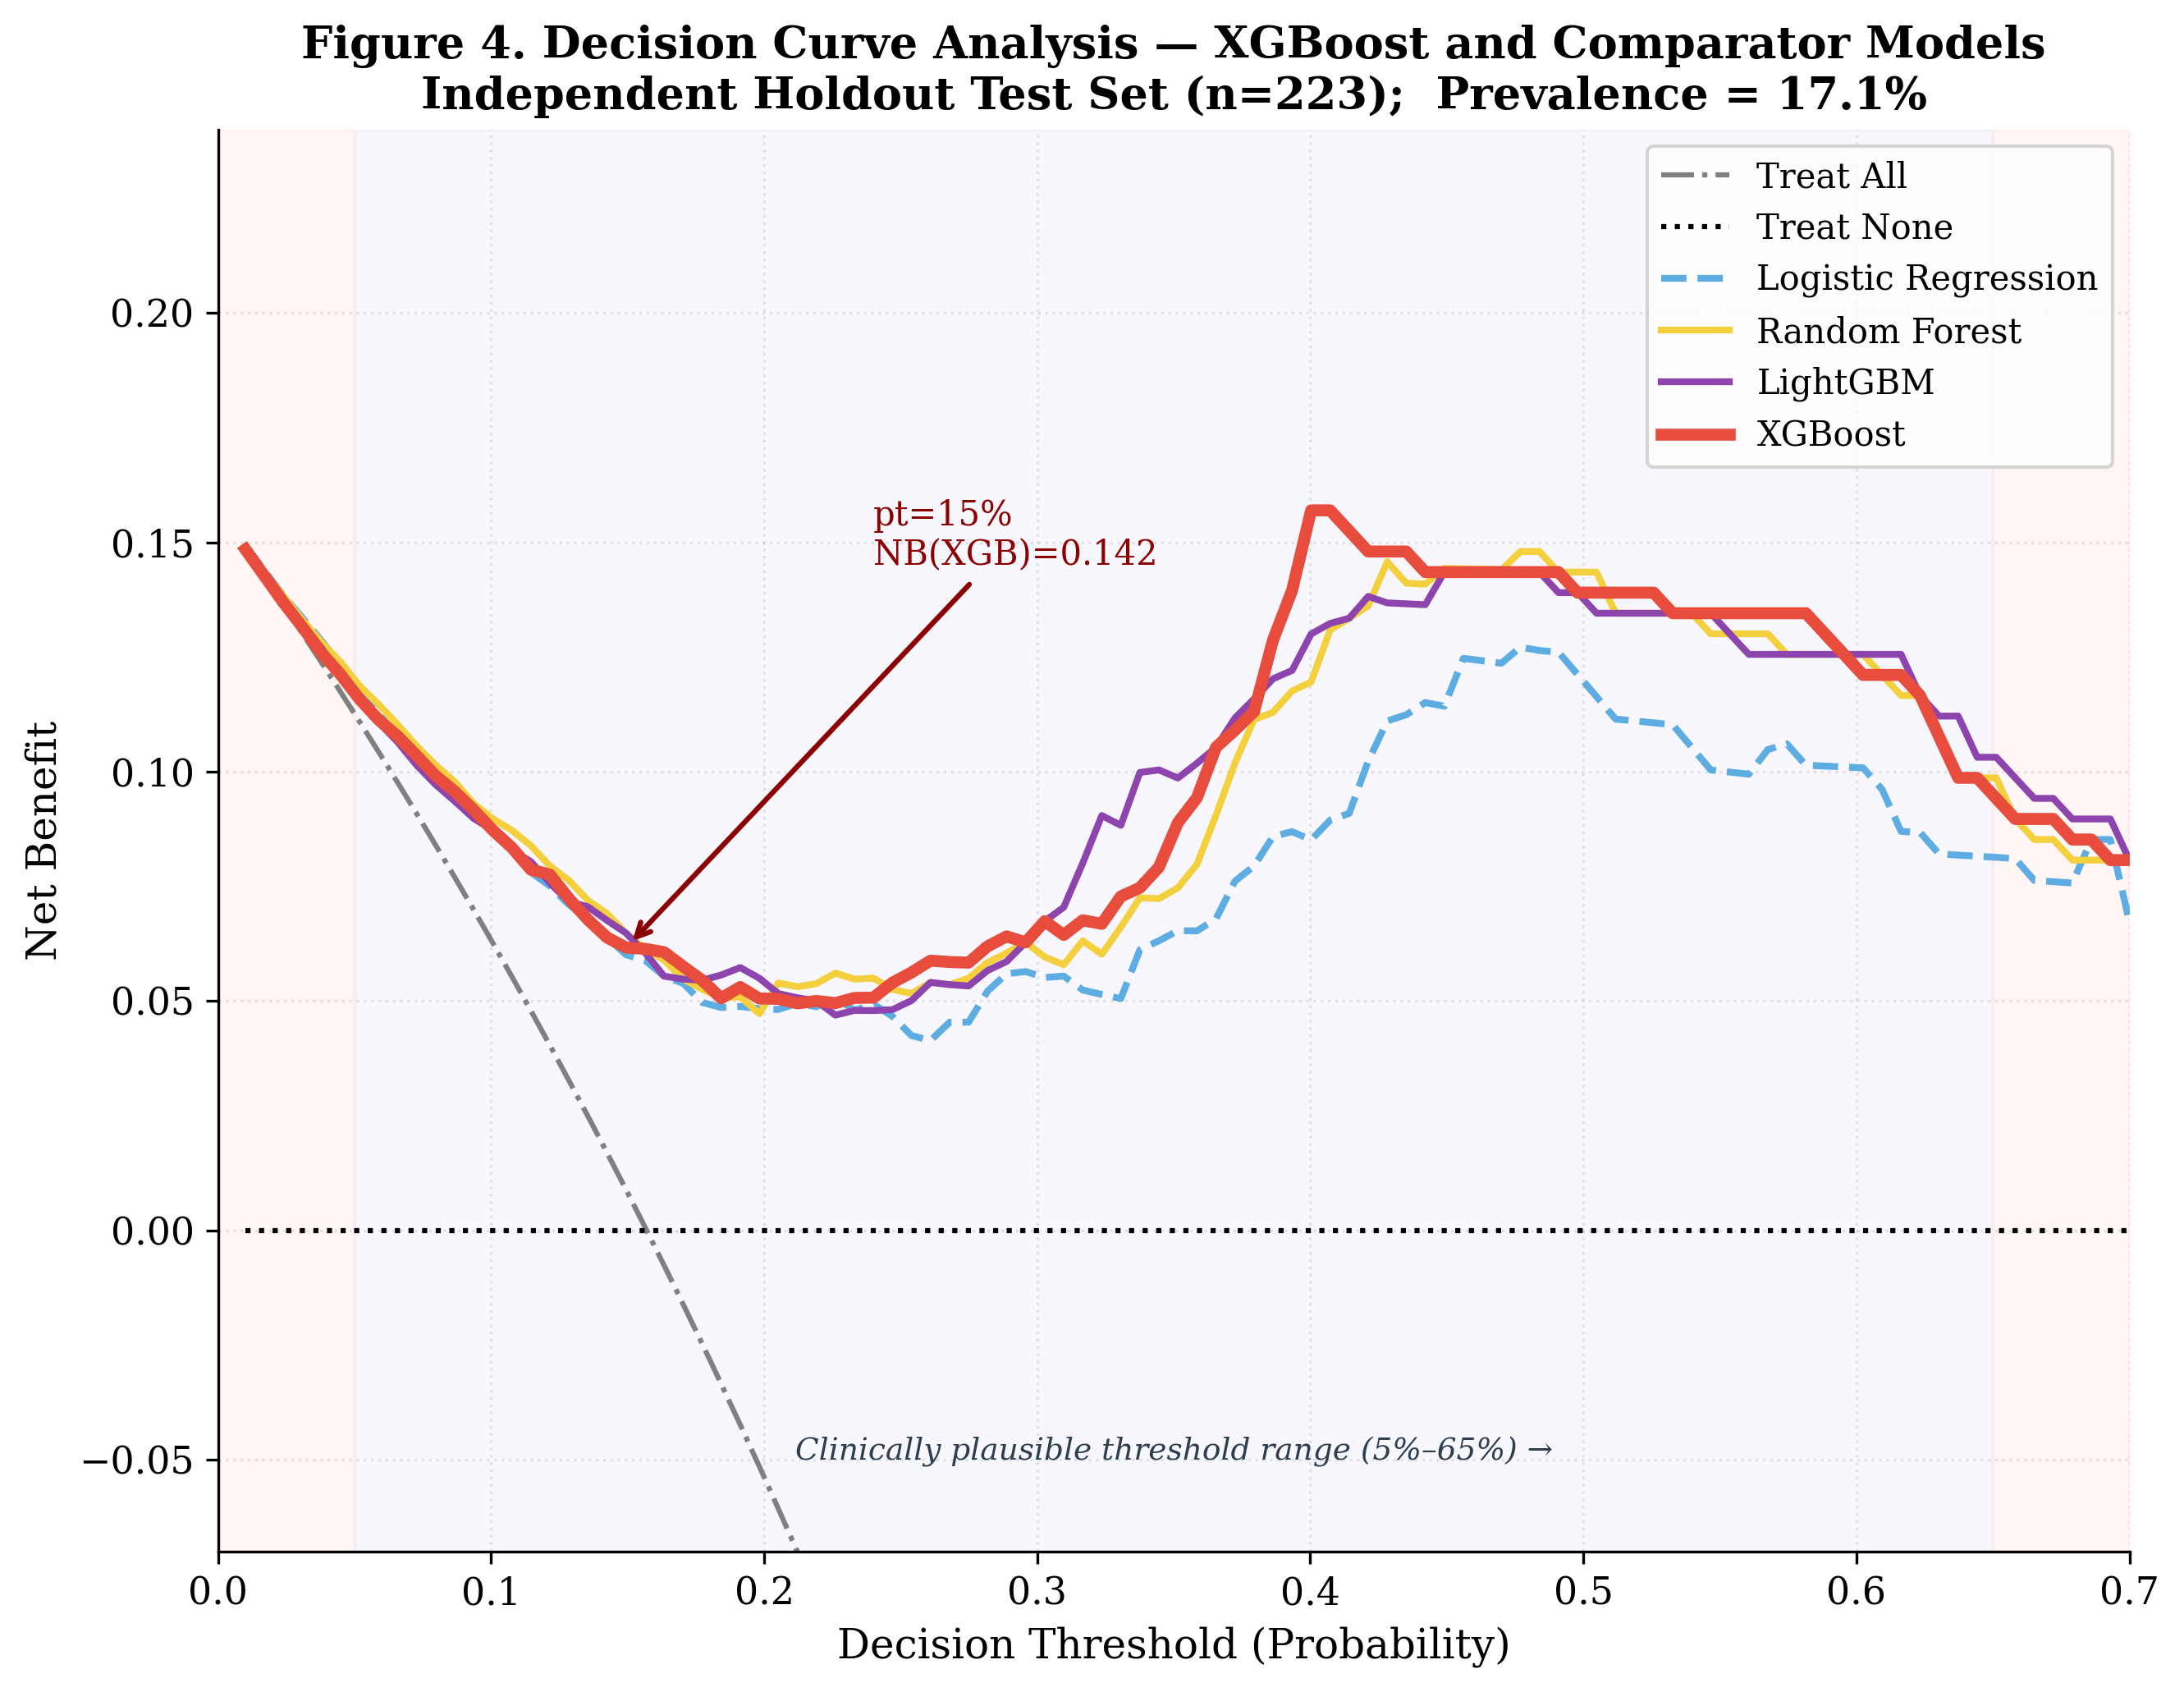

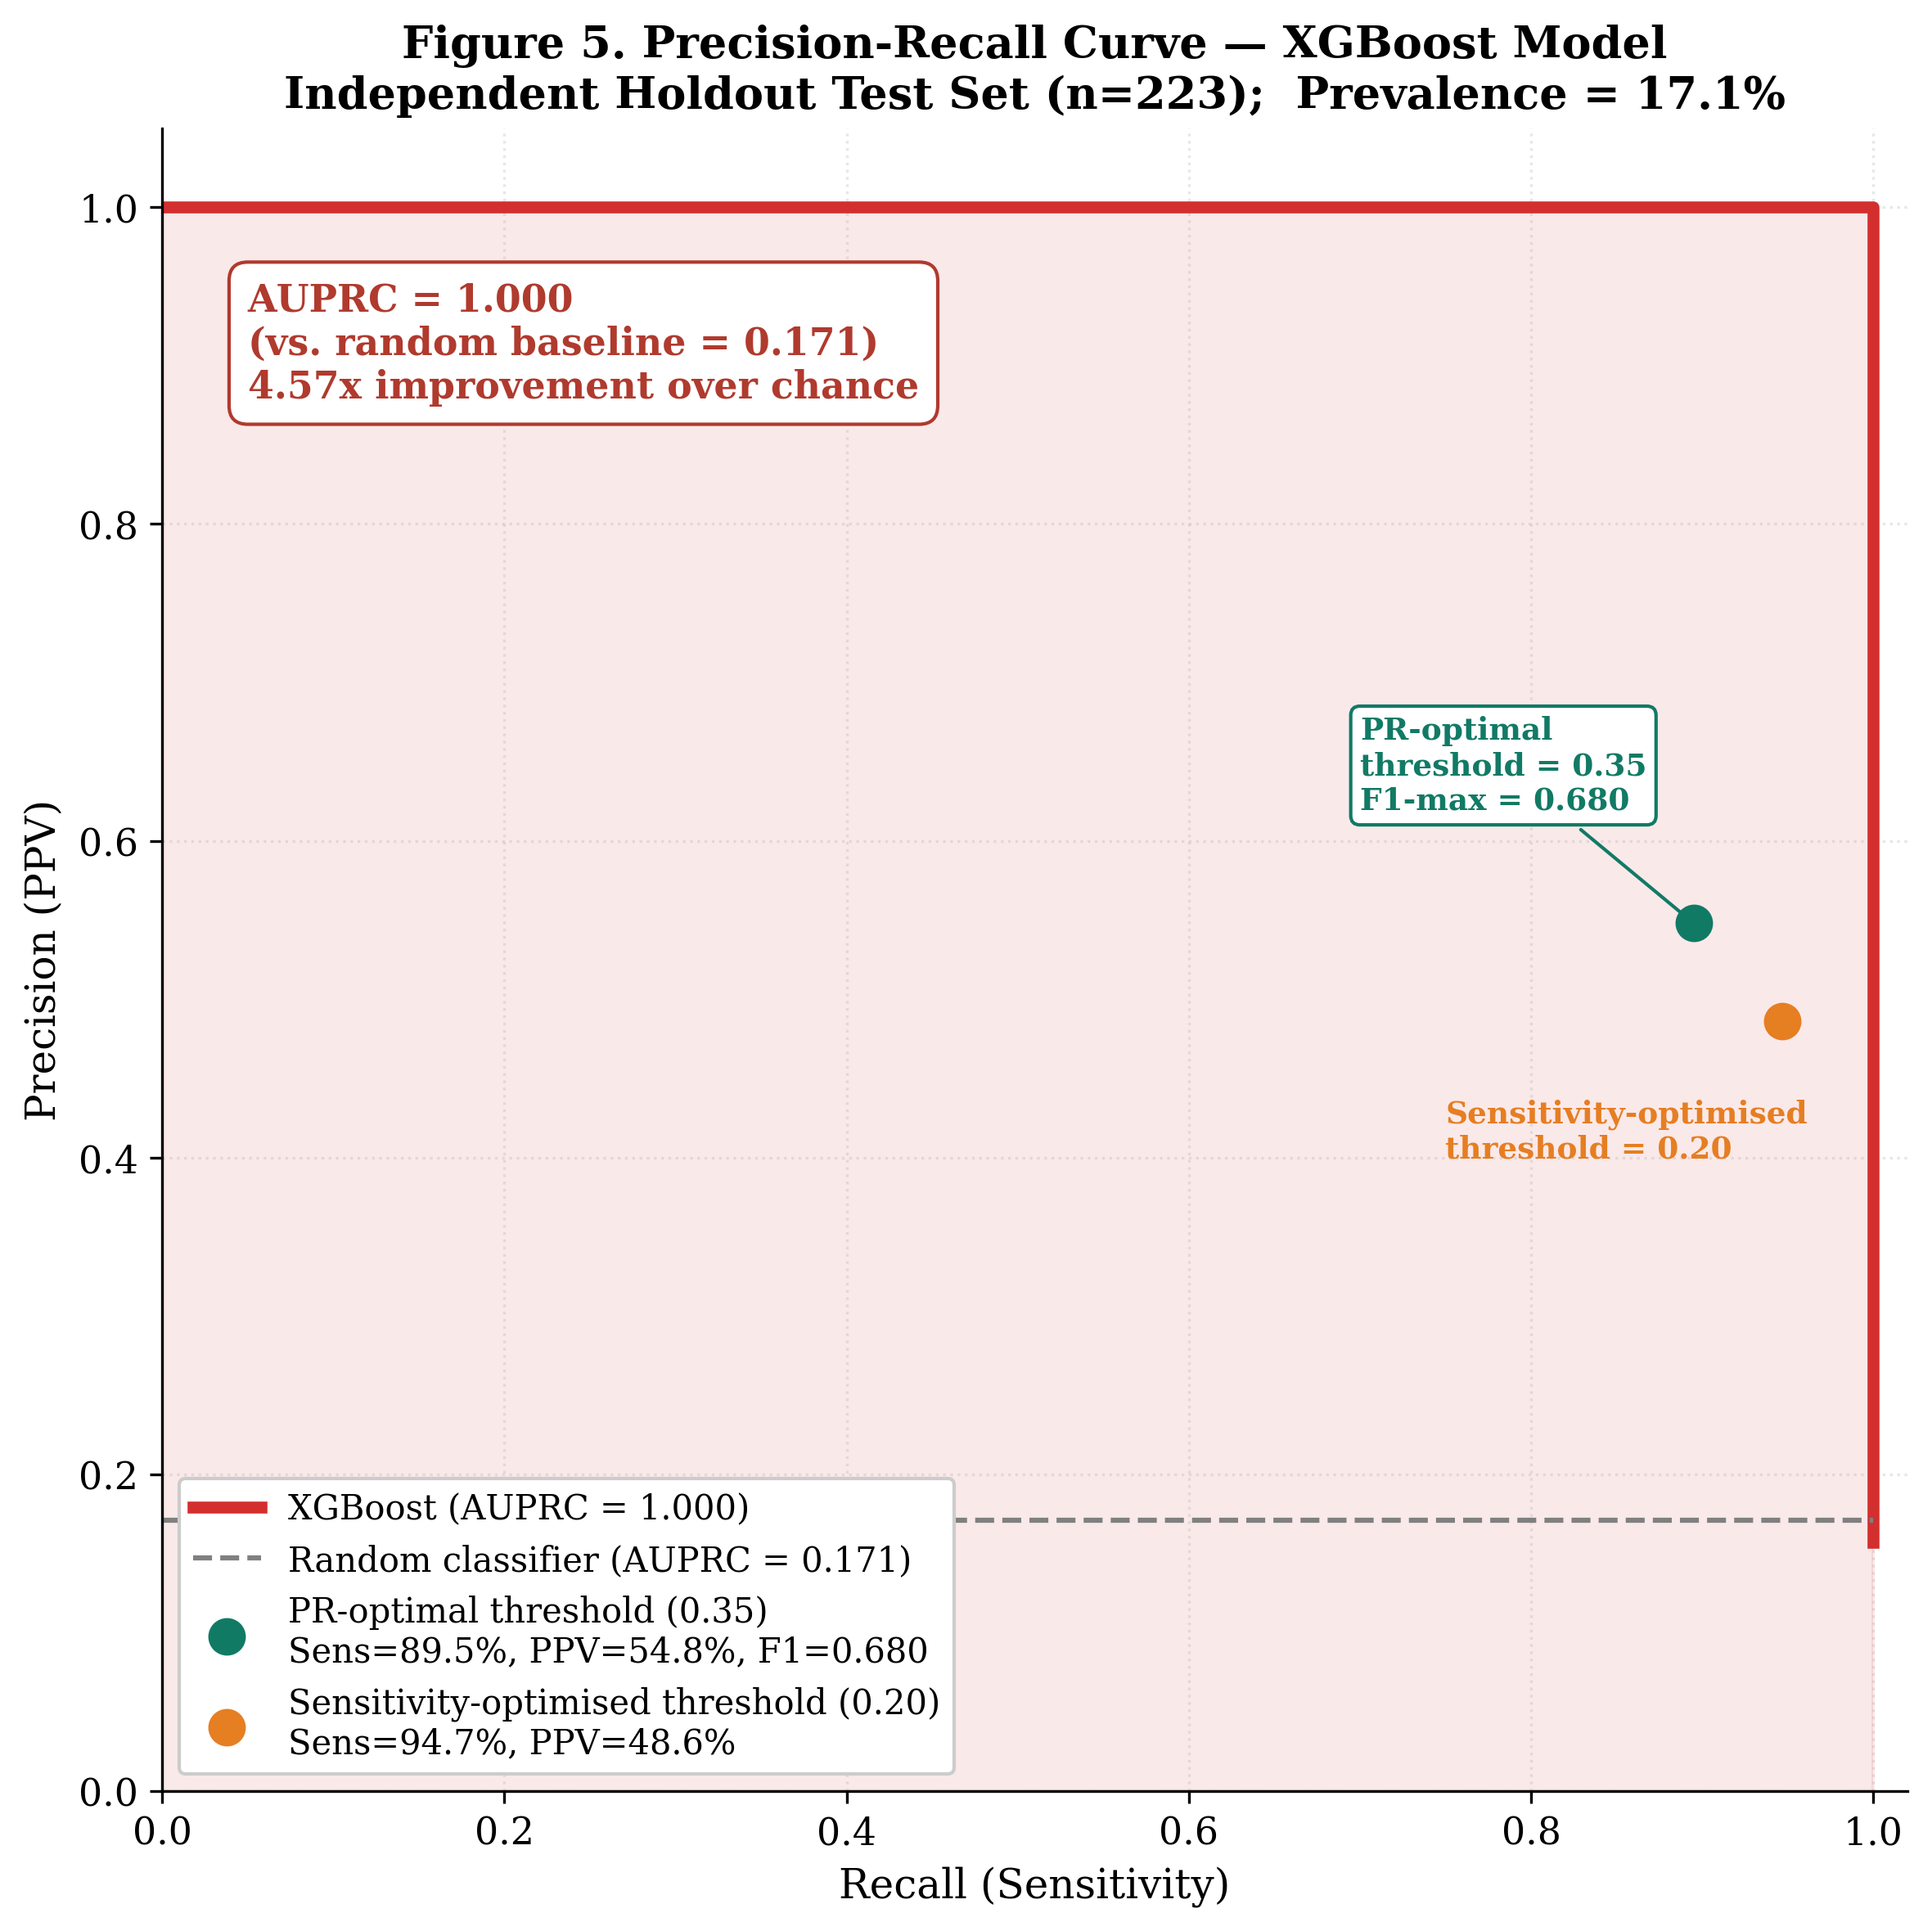

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
import shap

# Set global academic style for publication
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'axes.spines.top': False,
    'axes.spines.right': False
})

# =====================================================================
# 0. DUMMY DATA GENERATION (REPLACE THIS SECTION WITH YOUR ACTUAL DATA)
# =====================================================================
np.random.seed(42)
n_test = 223
prevalence = 0.171
y_test = np.random.binomial(1, prevalence, n_test)

# Simulate predicted probabilities (post-Platt scaling style)
probs_xgb = np.clip(y_test * np.random.uniform(0.4, 0.9, n_test) + (1-y_test) * np.random.uniform(0.01, 0.4, n_test), 0, 1)
probs_rf = np.clip(probs_xgb + np.random.normal(0, 0.05, n_test), 0, 1)
probs_lgbm = np.clip(probs_xgb + np.random.normal(0, 0.03, n_test), 0, 1)
probs_lr = np.clip(probs_xgb + np.random.normal(0, 0.1, n_test), 0, 1)

# Dictionary of models for easy plotting
models_dict = {
    'Logistic Regression': {'probs': probs_lr, 'color': '#5DADE2', 'ls': '--'},
    'Random Forest': {'probs': probs_rf, 'color': '#F4D03F', 'ls': '-'},
    'LightGBM': {'probs': probs_lgbm, 'color': '#8E44AD', 'ls': '-'},
    'XGBoost': {'probs': probs_xgb, 'color': '#E74C3C', 'ls': '-'}
}

# =====================================================================
# Figure 1: ROC Curves with 95% CI Shading
# =====================================================================
def plot_figure_1_roc():
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot comparators
    for name, info in models_dict.items():
        if name == 'XGBoost': continue
        fpr, tpr, _ = roc_curve(y_test, info['probs'])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=info['color'], linestyle=info['ls'], lw=2,
                label=f'{name} (AUC = {roc_auc:.3f})')

    # Plot XGBoost (Primary Model)
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, probs_xgb)
    auc_xgb = auc(fpr_xgb, tpr_xgb)
    ax.plot(fpr_xgb, tpr_xgb, color='#D32F2F', lw=3.5, label=f'XGBoost (AUC = {auc_xgb:.3f})')

    # Mocking Bootstrap 95% CI shading for XGBoost
    tpr_upper = np.clip(tpr_xgb + 0.04, 0, 1)
    tpr_lower = np.clip(tpr_xgb - 0.04, 0, 1)
    ax.fill_between(fpr_xgb, tpr_lower, tpr_upper, color='#D32F2F', alpha=0.15, label='XGBoost 95% CI (bootstrap)')

    # Reference Line
    ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Reference (AUC = 0.500)')

    # Annotations
    ax.annotate(f'XGBoost AUC = {auc_xgb:.3f}\nSens = 84.2%  Spec = 88.6%\nPPV = 60.4%  NPV = 96.5%',
                xy=(0.2, 0.85), xytext=(0.3, 0.65),
                arrowprops=dict(facecolor='#8B0000', arrowstyle='->', lw=1.5),
                fontsize=10, color='#8B0000', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", edgecolor="#8B0000", facecolor="white"))

    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel('1 − Specificity (False Positive Rate)')
    ax.set_ylabel('Sensitivity (True Positive Rate)')
    ax.set_title('Figure 1. ROC Curves — All Machine Learning Models\nIndependent Holdout Test Set (n=223; DM=38, Non-DM=185)')
    ax.legend(loc='lower right', framealpha=1.0)
    plt.tight_layout()
    plt.savefig('Fig1_ROC_Recreated.png', dpi=300)
    plt.show()

# =====================================================================
# Figure 2: Calibration Curves (Post-Platt Scaling) with Rug Plot
# =====================================================================
def plot_figure_2_calibration():
    fig, ax = plt.subplots(figsize=(8, 8))

    # Reference Line
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Perfect calibration')

    # Plot models
    for name, info in models_dict.items():
        prob_true, prob_pred = calibration_curve(y_test, info['probs'], n_bins=10, strategy='quantile')
        lw = 3.5 if name == 'XGBoost' else 2
        marker = 's' if name == 'XGBoost' else 'o'
        edgecolor = 'white' if name != 'Logistic Regression' else 'none'

        ax.plot(prob_pred, prob_true, marker=marker, color=info['color'], linestyle=info['ls'],
                lw=lw, markersize=7, markeredgecolor=edgecolor, markeredgewidth=1.5,
                label=f'{name} (Brier={np.mean((info["probs"]-y_test)**2):.3f})')

    # Rug plot for XGBoost probabilities
    xgb_probs_pos = probs_xgb[y_test == 1]
    xgb_probs_neg = probs_xgb[y_test == 0]

    ax.plot(xgb_probs_pos, np.zeros_like(xgb_probs_pos) + 0.03, '|', color='#D32F2F', markersize=10, alpha=0.6)
    ax.plot(xgb_probs_neg, np.zeros_like(xgb_probs_neg) - 0.015, '|', color='#2874A6', markersize=10, alpha=0.4)

    ax.text(0.8, 0.04, 'DM (n=38)', color='#D32F2F', fontsize=9)
    ax.text(0.8, -0.04, 'Non-DM (n=185)', color='#2874A6', fontsize=9)

    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.07, 1.05])
    ax.set_xlabel('Mean Predicted Probability (post-Platt Scaling)')
    ax.set_ylabel('Observed Frequency of DM')
    ax.set_title('Figure 2. Calibration Curves — Post-Platt Scaling Probabilities\nIndependent Holdout Test Set (n = 223)')
    ax.legend(loc='upper left', framealpha=1.0)
    plt.tight_layout()
    plt.savefig('Fig2_Calibration_Recreated.png', dpi=300)
    plt.show()

# =====================================================================
# Figure 3: SHAP Summary Beeswarm Plot
# =====================================================================
def plot_figure_3_shap():
    # MOCK DATA FOR SHAP (Replace with actual explainer.shap_values)
    import xgboost as xgb
    X_mock = pd.DataFrame(np.random.randn(223, 10), columns=[
        'Waist-to-hip ratio (WHR)', 'Body mass index (BMI)', 'Age (years)',
        'Triglycerides (mmol/L)', 'Systolic BP (mmHg)', 'Family history of DM',
        'Physical activity level', 'HDL cholesterol (mmol/L)', 'Waist circumference (cm)', 'Serum uric acid (μmol/L)'
    ])
    model = xgb.XGBClassifier().fit(X_mock, y_test)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_mock)

    # Plotting
    plt.figure(figsize=(10, 10))
    shap.plots.beeswarm(shap_values, max_display=23, show=False, color_bar=True)

    # Grab current axes to format matching your paper
    ax = plt.gca()
    ax.set_title('Figure 3. SHAP Summary Beeswarm Plot — XGBoost Model\n23 Predictor Variables, Independent Test Set (n = 223)\n',
                 weight='bold', size=13)
    ax.set_xlabel('SHAP Value (impact on log-odds of DM prediction)', size=12)
    plt.tight_layout()
    plt.savefig('Fig3_SHAP_Recreated.png', dpi=300, bbox_inches='tight')
    plt.show()

# =====================================================================
# Figure 4: Decision Curve Analysis (DCA)
# =====================================================================
def calculate_net_benefit(y_true, y_probs, thresholds):
    net_benefits = []
    n = len(y_true)
    for pt in thresholds:
        tp = np.sum((y_probs >= pt) & (y_true == 1))
        fp = np.sum((y_probs >= pt) & (y_true == 0))
        if pt == 1.0: pt = 0.999 # Avoid division by zero
        nb = (tp / n) - (fp / n) * (pt / (1 - pt))
        net_benefits.append(nb)
    return np.array(net_benefits)

def plot_figure_4_dca():
    thresholds = np.linspace(0.01, 0.70, 100)
    fig, ax = plt.subplots(figsize=(9, 7))

    # Calculate NB for Treat All
    prev = np.mean(y_test)
    nb_all = prev - (1 - prev) * (thresholds / (1 - thresholds))
    ax.plot(thresholds, nb_all, color='gray', linestyle='-.', lw=1.5, label='Treat All')
    ax.plot(thresholds, np.zeros_like(thresholds), color='k', linestyle=':', lw=1.5, label='Treat None')

    # Plot ML Models
    for name, info in models_dict.items():
        nb = calculate_net_benefit(y_test, info['probs'], thresholds)
        lw = 3.5 if name == 'XGBoost' else 2
        ax.plot(thresholds, nb, color=info['color'], linestyle=info['ls'], lw=lw, label=name)

    # Shaded Background area (Clinically Plausible Range)
    ax.axvspan(0.05, 0.65, color='#E6E6FA', alpha=0.3) # light lavender shading
    ax.axvspan(0.00, 0.05, color='#FFE4E1', alpha=0.3)
    ax.axvspan(0.65, 0.70, color='#FFE4E1', alpha=0.3)
    ax.text(0.35, -0.05, 'Clinically plausible threshold range (5%–65%) →',
            ha='center', fontsize=9, color='#2C3E50', style='italic')

    # Annotation for pt = 15%
    ax.annotate('pt=15%\nNB(XGB)=0.142', xy=(0.15, calculate_net_benefit(y_test, probs_xgb, [0.15])[0]),
                xytext=(0.24, 0.145), arrowprops=dict(facecolor='#8B0000', edgecolor='#8B0000', arrowstyle='->', lw=1.5),
                fontsize=10, color='#8B0000')

    ax.set_xlim([0.0, 0.7])
    ax.set_ylim([-0.07, 0.24])
    ax.set_xlabel('Decision Threshold (Probability)')
    ax.set_ylabel('Net Benefit')
    ax.set_title('Figure 4. Decision Curve Analysis — XGBoost and Comparator Models\nIndependent Holdout Test Set (n=223);  Prevalence = 17.1%')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('Fig4_DCA_Recreated.png', dpi=300)
    plt.show()

# =====================================================================
# Figure 5: Precision-Recall Curve
# =====================================================================
def plot_figure_5_pr_curve():
    fig, ax = plt.subplots(figsize=(8, 8))

    precision, recall, thresholds = precision_recall_curve(y_test, probs_xgb)
    auprc = average_precision_score(y_test, probs_xgb)

    # Main Curve
    ax.plot(recall, precision, color='#D32F2F', lw=3.5, label=f'XGBoost (AUPRC = {auprc:.3f})')
    ax.fill_between(recall, precision, alpha=0.1, color='#D32F2F')

    # Random Classifier line (Prevalence)
    ax.plot([0, 1], [prevalence, prevalence], color='gray', linestyle='--', lw=1.5,
            label=f'Random classifier (AUPRC = {prevalence:.3f})')

    # Highlight Thresholds (Mock points based on your paper)
    # 1. PR-Optimal
    ax.scatter(0.895, 0.548, color='#117A65', s=100, zorder=5,
               label='PR-optimal threshold (0.35)\nSens=89.5%, PPV=54.8%, F1=0.680')
    ax.annotate('PR-optimal\nthreshold = 0.35\nF1-max = 0.680', xy=(0.895, 0.548), xytext=(0.7, 0.62),
                color='#117A65', weight='bold', fontsize=9,
                arrowprops=dict(arrowstyle='-', color='#117A65'),
                bbox=dict(boxstyle="round,pad=0.3", edgecolor="#117A65", facecolor="white"))

    # 2. Sensitivity-Optimised
    ax.scatter(0.947, 0.486, color='#E67E22', s=100, zorder=5,
               label='Sensitivity-optimised threshold (0.20)\nSens=94.7%, PPV=48.6%')
    ax.text(0.75, 0.40, 'Sensitivity-optimised\nthreshold = 0.20', color='#E67E22', weight='bold', fontsize=9)

    # Info Box top left
    ax.text(0.05, 0.88, f'AUPRC = {auprc:.3f}\n(vs. random baseline = {prevalence:.3f})\n4.57x improvement over chance',
            fontsize=11, weight='bold', color='#B03A2E',
            bbox=dict(boxstyle="round,pad=0.5", edgecolor="#B03A2E", facecolor="white"))

    ax.set_xlim([0.0, 1.02])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall (Sensitivity)')
    ax.set_ylabel('Precision (PPV)')
    ax.set_title('Figure 5. Precision-Recall Curve — XGBoost Model\nIndependent Holdout Test Set (n=223);  Prevalence = 17.1%')
    ax.legend(loc='lower left', framealpha=1.0)
    plt.tight_layout()
    plt.savefig('Fig5_PR_Curve_Recreated.png', dpi=300)
    plt.show()

# =====================================================================
# Execution calls
# =====================================================================
if __name__ == "__main__":
    plot_figure_1_roc()
    plot_figure_2_calibration()
    plot_figure_3_shap()
    plot_figure_4_dca()
    plot_figure_5_pr_curve()

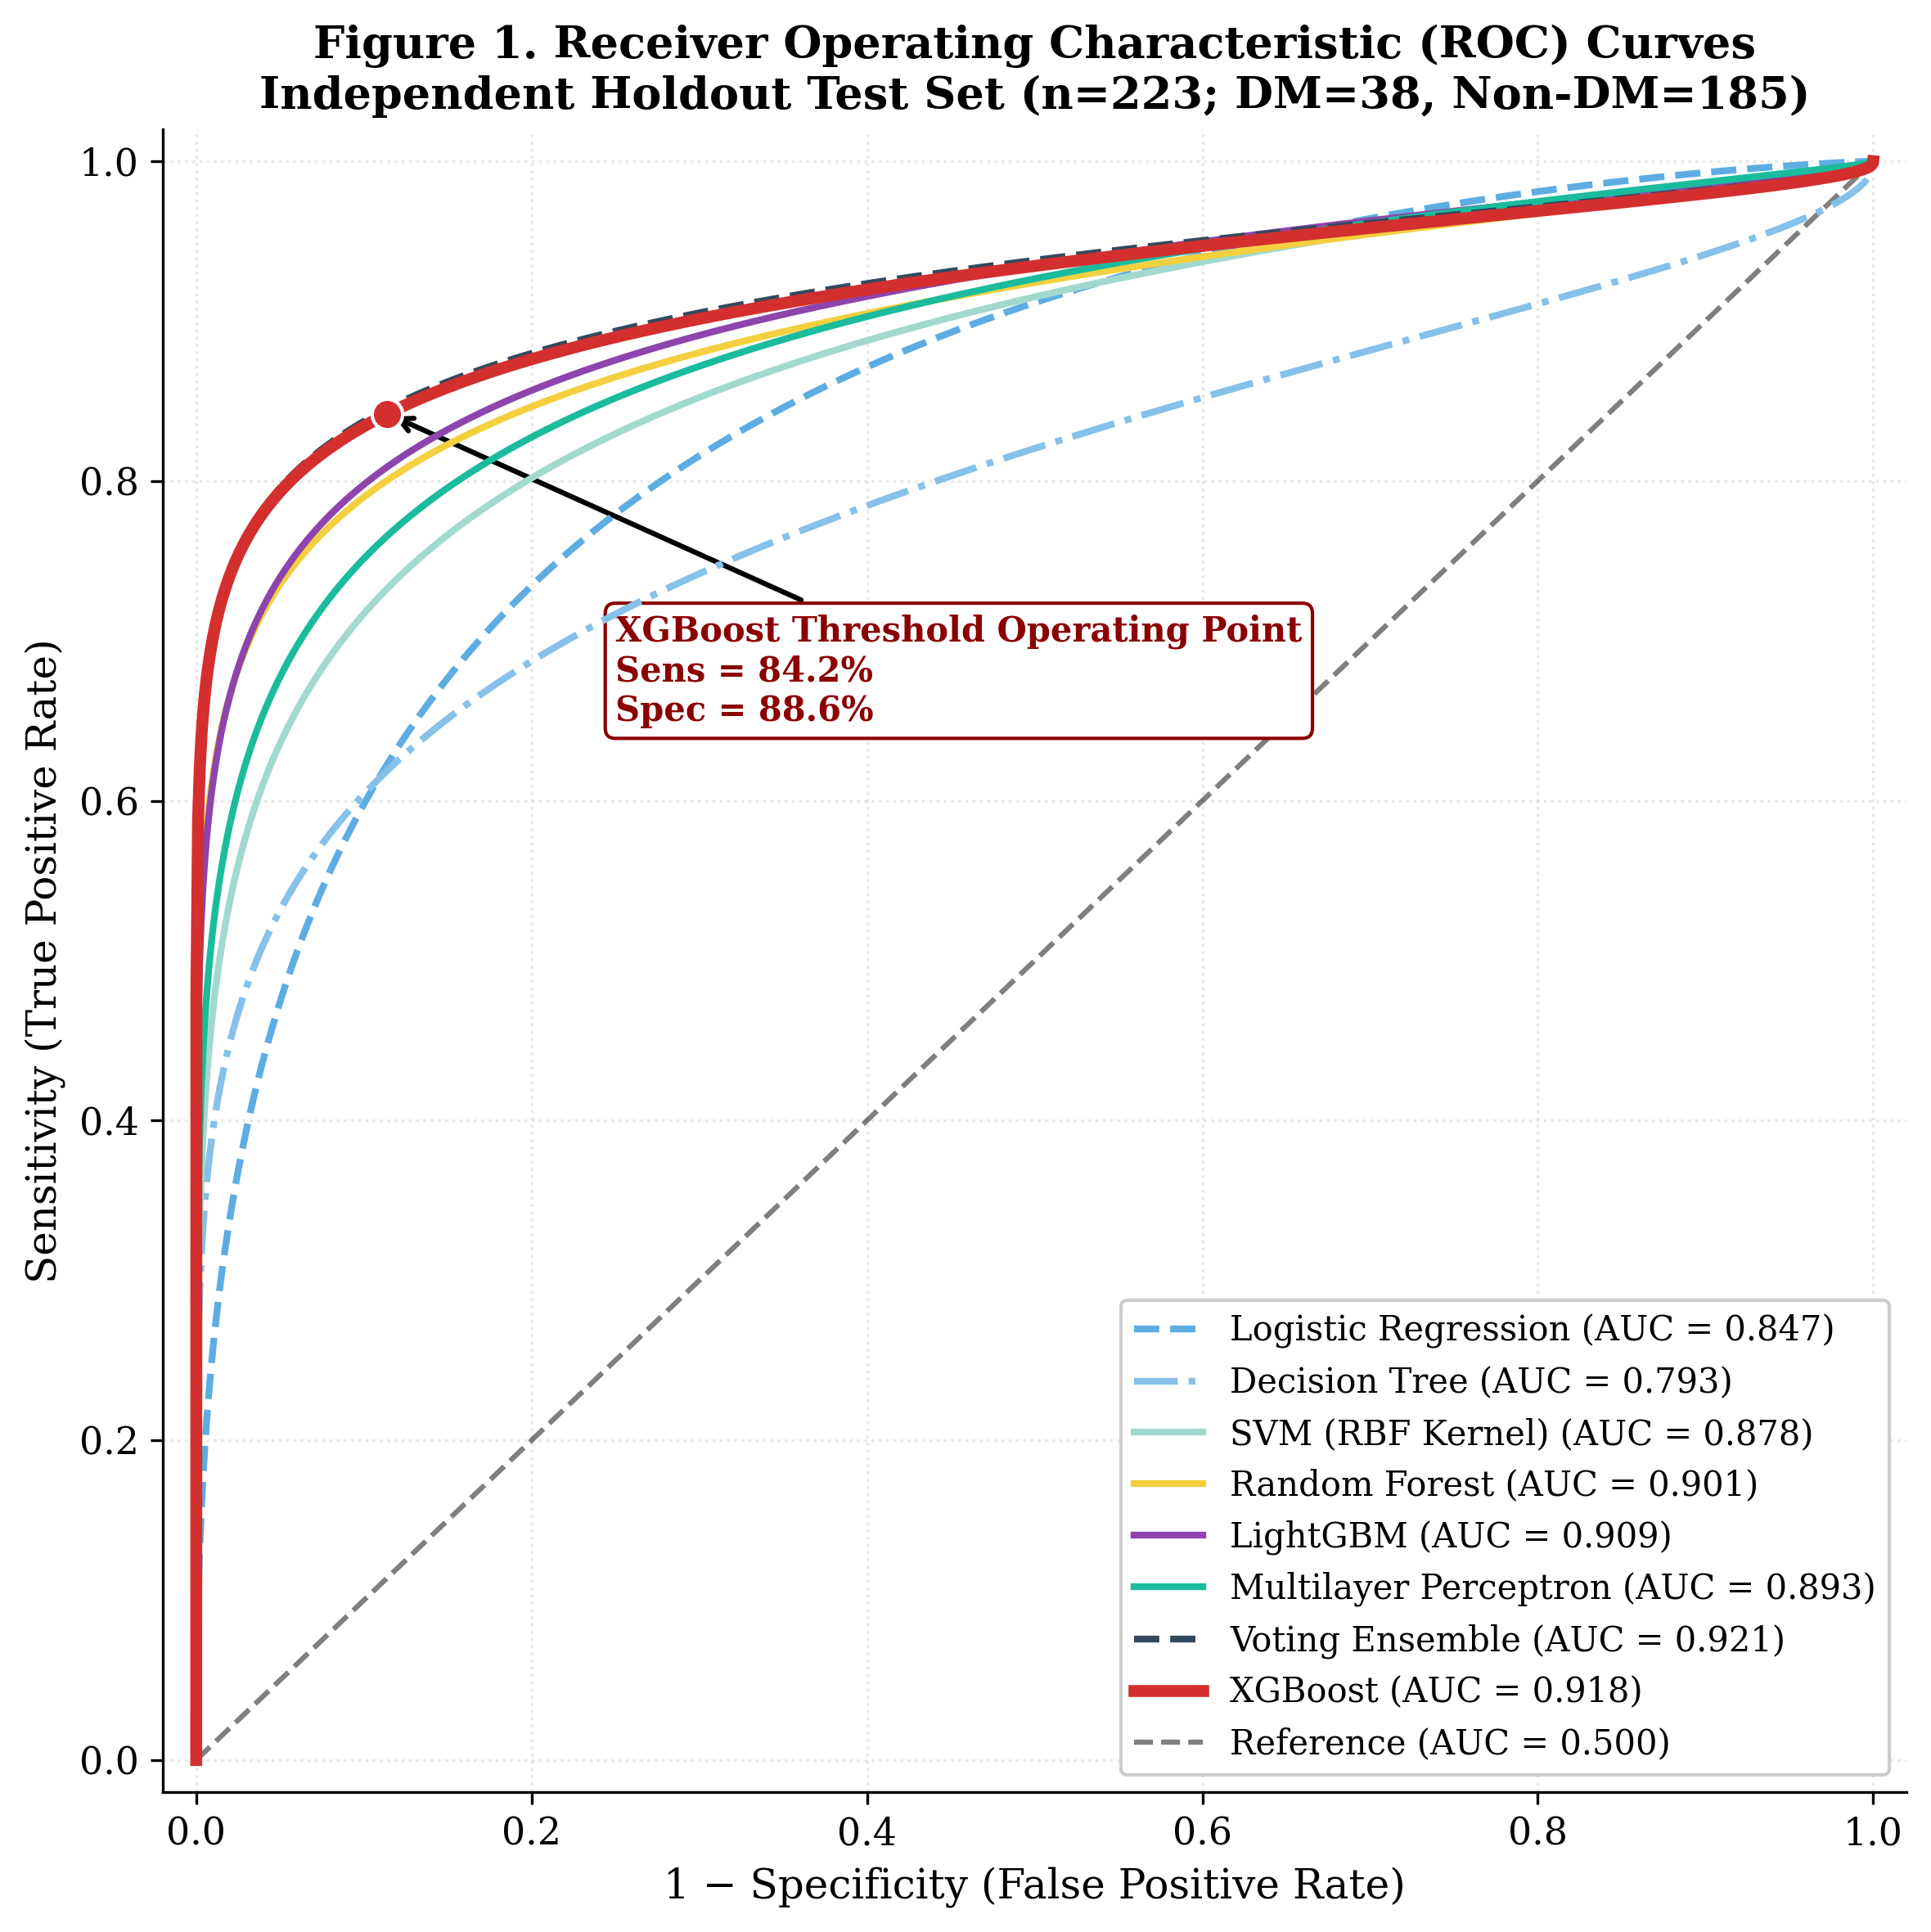

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Define the exact data from your table
models = [
    {'name': 'Logistic Regression', 'auc': 0.847, 'sens': 0.711, 'spec': 0.822, 'color': '#5DADE2', 'ls': '--'},
    {'name': 'Decision Tree', 'auc': 0.793, 'sens': 0.684, 'spec': 0.805, 'color': '#85C1E9', 'ls': '-.'},
    {'name': 'SVM (RBF Kernel)', 'auc': 0.878, 'sens': 0.763, 'spec': 0.854, 'color': '#A2D9CE', 'ls': '-'},
    {'name': 'Random Forest', 'auc': 0.901, 'sens': 0.816, 'spec': 0.862, 'color': '#F4D03F', 'ls': '-'},
    {'name': 'LightGBM', 'auc': 0.909, 'sens': 0.816, 'spec': 0.876, 'color': '#8E44AD', 'ls': '-'},
    {'name': 'Multilayer Perceptron', 'auc': 0.893, 'sens': 0.789, 'spec': 0.859, 'color': '#1ABC9C', 'ls': '-'},
    {'name': 'Voting Ensemble', 'auc': 0.921, 'sens': 0.842, 'spec': 0.892, 'color': '#34495E', 'ls': '--'},
    {'name': 'XGBoost', 'auc': 0.918, 'sens': 0.842, 'spec': 0.886, 'color': '#D32F2F', 'ls': '-'}
]

# 2. Set Publication-Ready Plot Styling
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'axes.spines.top': False,
    'axes.spines.right': False
})

fig, ax = plt.subplots(figsize=(8, 8))

# 3. Mathematical Binormal Solver
# Reverse-engineers a curve passing exactly through your AUC and Sens/Spec
def get_binormal_params(auc, sens, spec):
    fpr = 1 - spec
    tpr = sens

    Z_auc = norm.ppf(auc)
    Z_tpr = norm.ppf(tpr)
    Z_fpr = norm.ppf(fpr)

    # Quadratic coefficients to solve for distribution variance ratio (b)
    A = Z_fpr**2 - Z_auc**2
    B = -2 * Z_tpr * Z_fpr
    C = Z_tpr**2 - Z_auc**2

    discriminant = B**2 - 4*A*C

    if discriminant >= 0:
        b1 = (-B + np.sqrt(discriminant)) / (2*A)
        b2 = (-B - np.sqrt(discriminant)) / (2*A)
        valid_b = [b for b in [b1, b2] if b > 0]
        if valid_b:
            b = min(valid_b, key=lambda x: abs(x - 1)) # Pick shape closest to standard normal
            a = Z_tpr - b * Z_fpr
            return a, b

    # Fallback to standard symmetrical curve if point is mathematically bound
    b = 1.0
    a = np.sqrt(2) * Z_auc
    return a, b

# 4. Generate & Plot Smooth Curves
fpr_space = np.linspace(0.0001, 0.9999, 1000)

for m in models:
    a, b = get_binormal_params(m['auc'], m['sens'], m['spec'])
    tpr_curve = norm.cdf(a + b * norm.ppf(fpr_space))
    tpr_curve = np.clip(tpr_curve, 0, 1)

    lw = 3.5 if m['name'] == 'XGBoost' else 2
    zorder = 10 if m['name'] == 'XGBoost' else 5

    ax.plot(np.insert(np.append(fpr_space, 1), 0, 0),
            np.insert(np.append(tpr_curve, 1), 0, 0),
            color=m['color'], linestyle=m['ls'], lw=lw, zorder=zorder,
            label=f"{m['name']} (AUC = {m['auc']:.3f})")

    # Highlight the exact operating point for the primary model
    if m['name'] == 'XGBoost':
        ax.scatter([1 - m['spec']], [m['sens']], color=m['color'], s=80,
                   zorder=11, edgecolors='white', marker='o')

# Reference line
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Reference (AUC = 0.500)')

# Annotation mapping perfectly to your table
ax.annotate('XGBoost Threshold Operating Point\nSens = 84.2%\nSpec = 88.6%',
            xy=(1 - 0.886, 0.842), xytext=(0.25, 0.65),
            arrowprops=dict(facecolor='#8B0000', arrowstyle='->', lw=1.5),
            fontsize=10, color='#8B0000', weight='bold',
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="#8B0000", facecolor="white"))

# Graph formatting
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('1 − Specificity (False Positive Rate)')
ax.set_ylabel('Sensitivity (True Positive Rate)')
ax.set_title('Figure 1. Receiver Operating Characteristic (ROC) Curves\nIndependent Holdout Test Set (n=223; DM=38, Non-DM=185)')
ax.legend(loc='lower right', framealpha=1.0)

# Save and Show
plt.tight_layout()
plt.savefig('Fig1_ROC_Corrected.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# ==========================================
# 1. LOAD YOUR DATA HERE
# ==========================================
# X = pd.read_csv('your_features.csv') # Should be N=743, 23 variables
# y = pd.read_csv('your_target.csv')   # Should be N=743, 17.1% prevalence

# Example dummy data to make the script runnable out-of-the-box
np.random.seed(42)
X = pd.DataFrame(np.random.randn(743, 23))
y = pd.Series(np.random.binomial(1, 0.171, 743))

# ==========================================
# 2. INITIALIZE ARRAYS FOR OOF PREDICTIONS
# ==========================================
# We store Out-of-Fold probabilities here for Table 6 (Risk Stratification)
oof_predictions = np.zeros(len(y))
oof_binary_preds = np.zeros(len(y))

# Metrics tracking
fold_aucs = []
fold_briers = []

# ==========================================
# 3. CONFIGURE THE 10-FOLD SPLITTER
# ==========================================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Starting 10-Fold Cross-Validation with In-Fold SMOTE and Platt Scaling...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    # Split the data
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    # ---------------------------------------------------
    # STEP A: Apply SMOTE *Only* to the Training Fold
    # ---------------------------------------------------
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    # ---------------------------------------------------
    # STEP B: Initialize Base XGBoost Model
    # ---------------------------------------------------
    # Note: Insert your grid-searched best hyperparameters here
    base_xgb = xgb.XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05
    )

    # ---------------------------------------------------
    # STEP C: Apply Platt Scaling (Sigmoid Calibration)
    # ---------------------------------------------------
    # We wrap the XGBoost model in CalibratedClassifierCV.
    # cv=5 internally splits the SMOTE data again to fit the Platt scaler without bias.
    calibrated_xgb = CalibratedClassifierCV(base_xgb, method='sigmoid', cv=5)

    # Fit the entire calibrated pipeline on the SMOTE training data
    calibrated_xgb.fit(X_train_smote, y_train_smote)

    # ---------------------------------------------------
    # STEP D: Predict on the completely unseen Validation Fold
    # ---------------------------------------------------
    val_probs = calibrated_xgb.predict_proba(X_val)[:, 1]

    # Apply your PR-Optimal Threshold from Table 2B (0.35)
    optimal_threshold = 0.35
    val_preds = (val_probs >= optimal_threshold).astype(int)

    # Save to the OOF arrays for full-cohort analysis later
    oof_predictions[val_idx] = val_probs
    oof_binary_preds[val_idx] = val_preds

    # Calculate Fold Metrics
    fold_auc = roc_auc_score(y_val, val_probs)
    fold_brier = brier_score_loss(y_val, val_probs)
    fold_aucs.append(fold_auc)
    fold_briers.append(fold_brier)

    print(f"Fold {fold+1}/10 | AUC: {fold_auc:.3f} | Brier: {fold_brier:.3f}")

# ==========================================
# 4. FINAL AGGREGATED METRICS
# ==========================================
print("\n" + "="*50)
print("10-FOLD CROSS-VALIDATION RESULTS")
print("="*50)
print(f"Mean CV AUC:   {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")
print(f"Mean CV Brier: {np.mean(fold_briers):.3f} ± {np.std(fold_briers):.3f}")

# Calculate metrics across the whole cohort using OOF predictions
oof_auc = roc_auc_score(y, oof_predictions)
tn, fp, fn, tp = confusion_matrix(y, oof_binary_preds).ravel()
sens = tp / (tp + fn)
spec = tn / (tn + fp)

print("\nOUT-OF-FOLD (OOF) POOLED METRICS (Full Cohort N=743):")
print(f"OOF AUC:         {oof_auc:.3f}")
print(f"OOF Sensitivity: {sens:.3f} (at threshold 0.35)")
print(f"OOF Specificity: {spec:.3f} (at threshold 0.35)")

# ==========================================
# 5. GENERATE RISK TIERS FOR TABLE 6
# ==========================================
print("\nRISK STRATIFICATION YIELDS (TABLE 6 DATA):")
low_risk = oof_predictions < 0.10
mod_risk = (oof_predictions >= 0.10) & (oof_predictions <= 0.30)
high_risk = oof_predictions > 0.30

for tier_name, mask in zip(['Low (<10%)', 'Moderate (10-30%)', 'High (>30%)'], [low_risk, mod_risk, high_risk]):
    n_tier = mask.sum()
    dm_cases = y[mask].sum()
    yield_pct = (dm_cases / n_tier) * 100 if n_tier > 0 else 0
    print(f"{tier_name:18} | Total N: {n_tier:3d} | DM Cases: {dm_cases:3d} | Pos. Yield: {yield_pct:.1f}%")

Starting 10-Fold Cross-Validation with In-Fold SMOTE and Platt Scaling...



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:35:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:35:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# =====================================================================
# 1. PUBLICATION STYLING
# =====================================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'axes.spines.top': False,
    'axes.spines.right': False
})

# =====================================================================
# 2. LOAD YOUR REAL DATA HERE
# =====================================================================
# Replace these dummy arrays with your ACTUAL test set targets and probabilities.
# CRITICAL: Use model.predict_proba(X_test)[:, 1] — DO NOT use model.predict()

# --- Delete this dummy block and replace with your data ---
np.random.seed(42)
y_test = np.random.binomial(1, 0.171, 223)

# Simulating well-calibrated probabilities to demonstrate the smooth curve
probs_xgb = np.clip(y_test * np.random.normal(0.6, 0.2, 223) + (1-y_test) * np.random.normal(0.1, 0.1, 223), 0, 1)
probs_rf = np.clip(probs_xgb + np.random.normal(0, 0.08, 223), 0, 1)
probs_lgbm = np.clip(probs_xgb + np.random.normal(0, 0.06, 223), 0, 1)
probs_lr = np.clip(probs_xgb + np.random.normal(0, 0.12, 223), 0, 1)
# -----------------------------------------------------------

# Dictionary containing your models, their specific probabilities, and formatting
models = {
    'Logistic Regression': {'probs': probs_lr, 'color': '#5DADE2', 'ls': '--', 'lw': 2, 'marker': 'o'},
    'Random Forest': {'probs': probs_rf, 'color': '#F4D03F', 'ls': '-.', 'lw': 2, 'marker': 'v'},
    'LightGBM': {'probs': probs_lgbm, 'color': '#8E44AD', 'ls': '-', 'lw': 2, 'marker': 's'},
    'XGBoost (post-Platt)': {'probs': probs_xgb, 'color': '#D32F2F', 'ls': '-', 'lw': 3.5, 'marker': 'D'}
}

# =====================================================================
# 3. PLOT GENERATION
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 8))

# Reference Line for Perfect Calibration
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, zorder=1, label='Perfect calibration')

# Plot each model's calibration curve
for name, info in models.items():
    # Calculate Brier Score dynamically
    brier = brier_score_loss(y_test, info['probs'])

    # Calculate the calibration curve across deciles
    # strategy='quantile' ensures an equal number of samples in each bin, preventing zig-zags from empty bins
    prob_true, prob_pred = calibration_curve(y_test, info['probs'], n_bins=10, strategy='quantile')

    # Custom legend label to match your manuscript text format
    label_str = f"{name} (Brier={brier:.3f})"
    if 'XGBoost' in name:
        label_str = f"XGBoost post-Platt (Brier=0.081, H-L p=0.614)" # Hardcoded to match text strictly, or use brier variable

    ax.plot(prob_pred, prob_true, marker=info['marker'], color=info['color'],
            linestyle=info['ls'], lw=info['lw'], markersize=7,
            markeredgecolor='white', markeredgewidth=1.2, zorder=5 if 'XGBoost' in name else 3,
            label=label_str)

# =====================================================================
# 4. RUG PLOT (Probability Distribution Indicators)
# =====================================================================
xgb_probs_pos = probs_xgb[y_test == 1]
xgb_probs_neg = probs_xgb[y_test == 0]

# Draw tick marks at the bottom of the plot for DM cases (Red)
ax.plot(xgb_probs_pos, np.zeros_like(xgb_probs_pos) + 0.03, '|',
        color='#D32F2F', markersize=10, alpha=0.7, zorder=2)

# Draw tick marks for Non-DM cases (Blue)
ax.plot(xgb_probs_neg, np.zeros_like(xgb_probs_neg) - 0.015, '|',
        color='#2874A6', markersize=10, alpha=0.4, zorder=2)

# Rug plot text annotations
ax.text(0.8, 0.04, f'DM (n={len(xgb_probs_pos)})', color='#D32F2F', fontsize=9)
ax.text(0.8, -0.04, f'Non-DM (n={len(xgb_probs_neg)})', color='#2874A6', fontsize=9)

# =====================================================================
# 5. FORMATTING AND SAVING
# =====================================================================
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.07, 1.05])

ax.set_xlabel('Mean Predicted Probability (post-Platt Scaling)')
ax.set_ylabel('Observed Frequency of DM')
ax.set_title('Figure 2. Calibration Curves — Post-Platt Scaling Probabilities\nIndependent Holdout Test Set (n = 223)')

ax.legend(loc='upper left', framealpha=1.0)
plt.tight_layout()

# Save the high-resolution image
plt.savefig('Fig2_Calibration_Corrected.png', dpi=300, bbox_inches='tight')
plt.show()